In [87]:
import numpy as np
from qibo import hamiltonians
from qibo.hamiltonians import SymbolicHamiltonian
from qibo.symbols import *
import matplotlib.pyplot as plt
from qibo.quantum_info.linalg_operations import commutator, matrix_exponentiation
from qibo import gates, Circuit
from single_qubit_tomography import *

def ptrace(matrix,n1=2,n2=2):
    current_tensor=matrix.reshape([n1, n2, n1, n2])
    return np.trace(current_tensor, axis1=1, axis2=3)

def off_diagonal_norm(H):
    diagonal_h = np.diag(np.diag(H))
    off_diag_h = H - diagonal_h
    off_diag_h_dag = np.asarray(np.asmatrix(off_diag_h).H)
    return np.sqrt(np.real(np.trace(off_diag_h_dag @ off_diag_h)))

ket_plus = np.array([[1/np.sqrt(2)],[1/np.sqrt(2)]])
ket_plus_density_matrix = np.outer(ket_plus,ket_plus)

ket_plus_plus = np.kron(ket_plus,ket_plus)
ket_plus_plus_density_matrix = np.outer(ket_plus_plus,ket_plus_plus)

sigma_Z_1q = SymbolicHamiltonian(Z(0),1)
sigma_Z_2q = SymbolicHamiltonian(Z(0),2)

Heisenberg = SymbolicHamiltonian(X(0)*X(1) + Y(0)*Y(1) + Z(0)*Z(1),2)
def dSWAP(t):
    return Heisenberg.exp(t/2)

bracket_matrix = commutator(sigma_Z_1q.matrix,ket_plus_density_matrix)
bracket = hamiltonians.Hamiltonian(1,bracket_matrix)

n = 4
times = np.linspace(0.001,1,20)

[Qibo 0.2.11|WARNING|2024-08-26 14:05:53]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [88]:
import random
from abc import abstractmethod

import numpy as np

from qibo import gates, models
from qibo.config import raise_error


class AbstractQuantumDynamicProgramming:

    def __init__(
        self, num_work_qubits, num_memory_qubits, steps, iterations_per_step, circuit=None
    ):
        self.num_work_qubits = int(num_work_qubits)
        self.num_memory_qubits = int(num_memory_qubits)

        self.list_id_work_reg = np.arange(0, num_work_qubits, 1)
        self.list_id_memory_reg = (
            np.arange(0, num_memory_qubits, 1) + num_work_qubits
        )

        self.id_current_memory_reg = self.list_id_memory_reg[0]
        self.id_current_work_reg = self.list_id_work_reg[0]

        self.steps = steps
        self.iterations_per_step = iterations_per_step
        
        self.list_id_current_memory_reg = self.list_id_memory_reg

        if circuit is None:
            self.c = models.Circuit(self.num_work_qubits + self.num_memory_qubits)
        else:
            self.c = circuit

    @abstractmethod
    def memory_usage_query_circuit(self):
        """Defines the memory usage query circuit."""
        raise_error(NotImplementedError)

    @abstractmethod
    def memory_call_circuit(self):
        """Executes the memory call circuit based on the selected memory type."""
        raise_error(NotImplementedError)

    def memory_qubits_initialization(self):
        """Initializes the memory qubits."""
        pass

    def trace_one_memory_qubit(self, qubit_reg):
        """Traces the user specified memory qubit."""
        self.c.add(gates.M(qubit_reg))

    def trace_all_memory_qubit(self):
        """Traces all memory qubits."""
        for qubit in self.list_id_current_memory_reg:
            self.c.add(gates.M(qubit))

    def memory_reg_delegation(self):
        """Uses a work qubit as an memory qubit."""
        pass

    def memory_index(self, id_reg):
        return list(self.list_id_memory_reg).index(id_reg)

    def increment_current_memory_register(self):
        """Increments the current memory register index."""
        current_memory_index = self.memory_index(
            self.id_current_memory_reg
        )
        self.id_current_memory_reg = list(self.list_id_memory_reg)[
            current_memory_index + 1
        ]

    def circuit_reset(self):
        """Resets the entire quantum circuit."""
        self.c = models.Circuit(self.num_work_qubits + self.num_memory_qubits)

    def return_circuit(self):
        """Return the whole circuit"""
        return self.c


class SequentialInstruction(AbstractQuantumDynamicProgramming):
    def memory_call_circuit(self):
        
        current_memory_index = self.memory_index(self.id_current_memory_reg)
        if self.steps == 1:
            self.list_id_current_memory_reg = self.list_id_memory_reg[
                current_memory_index : self.steps * self.iterations_per_step
                + current_memory_index
            ]

            self.memory_qubits_initialization()
            self.work_qubits_initialization()
            for _register in np.arange(0,self.iterations_per_step,1):
                self.memory_usage_query_circuit()
                self.trace_one_memory_qubit(self.id_current_memory_reg)
                if self.memory_index(self.id_current_memory_reg) + 1 < len(
                    list(self.list_id_current_memory_reg)
                ):
                    self.increment_current_memory_register()
                self.memory_reg_delegation()

        elif self.steps == 2:
            self.min_number_of_qubit_2_steps()
            next_step_list_id_memory_reg = []
            for _register in np.arange(0,self.iterations_per_step,1):
                self.list_id_current_memory_reg = self.list_id_memory_reg[
                    current_memory_index : self.steps * self.iterations_per_step
                    + current_memory_index
                ]

                self.memory_qubits_initialization()
                self.work_qubits_initialization()
                for _register in np.arange(0,self.iterations_per_step,1):
                    self.memory_usage_query_circuit()
                    self.trace_one_memory_qubit(self.id_current_memory_reg)
                    if self.memory_index(self.id_current_memory_reg) + 1 < len(
                        list(self.list_id_current_memory_reg)
                    ):
                        self.increment_current_memory_register()
                    self.memory_reg_delegation()
                    next_step_list_id_memory_reg

            self.list_id_current_memory_reg = []


            print('x')

    def min_number_of_qubit_2_steps(self):
        if self.num_memory_qubits + self.num_work_qubits < (self.iterations_per_step+1)*self.iterations_per_step + 1:
            raise_error(exception = ValueError, message='Not enough qubits to execute this circuit')


import numpy as np

from qibo import gates
from qibo.transpiler.unitary_decompositions import two_qubit_decomposition
from qibo.hamiltonians import SymbolicHamiltonian
from qibo.symbols import X, Y, Z

class ObliviousSchmidtDecompositionSingleQubit(SequentialInstruction):

    def __init__(
        self, t, num_work_qubits, num_memory_qubits, steps=1, iterations_per_step=1
    ):
        super().__init__(
            num_work_qubits, num_memory_qubits, steps, iterations_per_step, circuit=None
        )
        self.t = t
        self.id_current_work_reg = self.list_id_work_reg[0]

    def memory_usage_query_circuit(self):
        """Defines the memory usage query circuit."""
        self.c.add(gates.Unitary(sigma_Z_2q.exp(self.t),self.id_current_work_reg,self.id_current_memory_reg))
        self.c.add(gates.Unitary(dSWAP(self.t),self.id_current_work_reg,self.id_current_memory_reg))
        self.c.add(gates.Unitary(sigma_Z_2q.exp(-self.t), self.id_current_work_reg,self.id_current_memory_reg))

    def memory_qubits_initialization(self):
        """Initializes the memory qubits by applying the RX gate with a pi/2 rotation."""
        for memory_qubit in self.list_id_current_memory_reg:
            self.c.add(gates.RY(memory_qubit, np.pi / 2))

    def work_qubits_initialization(self):
        """Initializes the work qubits by applying the RX gate with a pi/2 rotation."""
        for work_qubit in self.list_id_work_reg:
            self.c.add(gates.RY(work_qubit, np.pi / 2))

    

In [89]:
times = np.linspace(0.0001,1,150)
norms_qdp_2_step= []
for t in times:
    instance = ObliviousSchmidtDecompositionSingleQubit(t,1,10,iterations_per_step=1)
    instance.memory_call_circuit()
    c=instance.c
    rho_I = single_qubit_tomography(c)
    norms_qdp_2_step.append(hamiltonians.Hamiltonian(1,rho_I).energy_fluctuation(ket_plus))

[Qibo 0.2.11|WARNING|2024-08-26 14:05:53]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.
[Qibo 0.2.11|WARNING|2024-08-26 14:05:53]: Calculating the dense form of a symbolic Hamiltonian. This operation is memory inefficient.


In [90]:
instance = ObliviousSchmidtDecompositionSingleQubit(t,1,3,iterations_per_step=3)
instance.memory_call_circuit()
c=instance.c
print(c.draw())

q0: ─RY─U─U─U───U─U─U───U─U─U───
q1: ─RY─U─U─U─M─|─|─|───|─|─|───
q2: ─RY─────────U─U─U─M─|─|─|───
q3: ─RY─────────────────U─U─U─M─


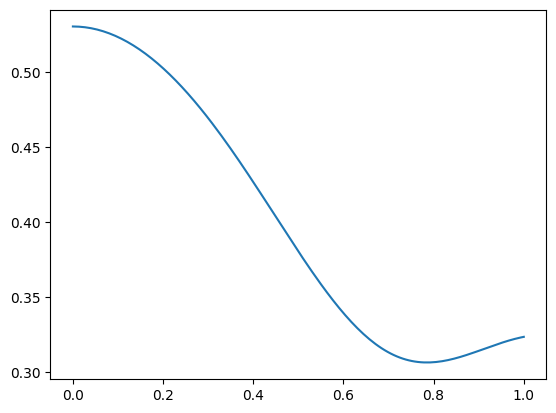

In [91]:
plt.plot(times,norms_qdp_2_step)